In [1]:
%matplotlib inline
from __future__ import print_function

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
dairy = pd.read_csv('C:/Users/Kat/OneDrive/Desktop/dairy_dataset.csv')

In [3]:
dairy.head(10)

,Location,Total Land Area (acres),Number of Cows,Farm Size,Date,Product ID,Product Name,Brand,Quantity (liters/kg),Price per Unit,...,Production Date,Expiration Date,Quantity Sold (liters/kg),Price per Unit (sold),Approx. Total Revenue(INR),Customer Location,Sales Channel,Quantity in Stock (liters/kg),Minimum Stock Threshold (liters/kg),Reorder Quantity (liters/kg)
0,Telangana,310.84,96,Medium,2022-02-17,5,Ice Cream,Dodla Dairy,222.40,85.72,...,2021-12-27,2022-01-21,7,82.24,575.68,Madhya Pradesh,Wholesale,215,19.55,64.03
1,Uttar Pradesh,19.19,44,Large,2021-12-01,1,Milk,Amul,687.48,42.61,...,2021-10-03,2021-10-25,558,39.24,21895.92,Kerala,Wholesale,129,43.17,181.10
2,Tamil Nadu,581.69,24,Medium,2022-02-28,4,Yogurt,Dodla Dairy,503.48,36.50,...,2022-01-14,2022-02-13,256,33.81,8655.36,Madhya Pradesh,Online,247,15.10,140.83
3,Telangana,908.00,89,Small,2019-06-09,3,Cheese,Britannia Industries,823.36,26.52,...,2019-05-15,2019-07-26,601,28.92,17380.92,Rajasthan,Online,222,74.50,57.68
4,Maharashtra,861.95,21,Medium,2020-12-14,8,Buttermilk,Mother Dairy,147.77,83.85,...,2020-10-17,2020-10-28,145,83.07,12045.15,Jharkhand,Retail,2,76.02,33.40
5,Telangana,87.64,51,Medium,2019-01-07,6,Curd,Raj,593.92,85.54,...,2019-01-03,2019-01-08,74,84.75,6271.50,Gujarat,Retail,519,55.60,139.59
6,Karnataka,73.28,74,Small,2022-08-05,3,Cheese,Dynamix Dairies,757.14,36.83,...,2022-06-14,2022-09-05,410,32.66,13390.60,Karnataka,Online,347,49.82,105.86
7,Bihar,67.61,77,Medium,2019-02-14,9,Paneer,Mother Dairy,203.36,29.08,...,2019-01-06,2019-01-20,15,29.09,436.35,Haryana,Online,188,10.90,25.14
8,West Bengal,72.31,76,Medium,2020-08-02,6,Curd,Raj,949.12,22.79,...,2020-06-06,2020-06-12,860,24.77,21302.20,Jharkhand,Wholesale,89,85.71,32.03
9,Telangana,413.24,36,Large,2022-03-04,8,Buttermilk,Mother Dairy,385.64,42.08,...,2022-02-03,2022-02-12,108,46.15,4984.20,Tamil Nadu,Retail,277,93.61,66.26


In [4]:
dairy.isnull().sum()

Location                               0
Total Land Area (acres)                0
Number of Cows                         0
Farm Size                              0
Date                                   0
Product ID                             0
Product Name                           0
Brand                                  0
Quantity (liters/kg)                   0
Price per Unit                         0
Total Value                            0
Shelf Life (days)                      0
Storage Condition                      0
Production Date                        0
Expiration Date                        0
Quantity Sold (liters/kg)              0
Price per Unit (sold)                  0
Approx. Total Revenue(INR)             0
Customer Location                      0
Sales Channel                          0
Quantity in Stock (liters/kg)          0
Minimum Stock Threshold (liters/kg)    0
Reorder Quantity (liters/kg)           0
dtype: int64

In [5]:
# original dataset
# Filter to milk only
milk_data = dairy[dairy["Product ID"] == 1]
milk_data = milk_data.rename(columns={
    "Quantity Sold (liters/kg)": "Quantity_Sold",
    "Price per Unit (sold)": "Price_sold"
})
# Check filtered data
print(milk_data["Brand"].unique())  # Verify the included brands- 4 INCLUDED 

['Amul' 'Mother Dairy' 'Raj' 'Sudha']


In [6]:
#work on creating model- using xgboost, others failed with high pvalue and low r squared- linear regression, poly regression, with or without milk, brand, location
available_columns = milk_data.columns
features = [
    "Price per Unit", "Shelf Life (days)", "Total Value", "Price_sold", 
    "Quantity in Stock (liters/kg)", "Minimum Stock Threshold (liters/kg)",
    "Reorder Quantity (liters/kg)", "Approx. Total Revenue(INR)", 
    "Storage Condition_Tetra Pack", "Farm Size_Medium", "Farm Size_Small",
    "Sales Channel_Retail", "Sales Channel_Wholesale"
] + [col for col in milk_data.columns if col.startswith("Location_")]

features = [col for col in features if col in available_columns]
X = milk_data[features].dropna()
y = milk_data["Quantity_Sold"].loc[X.index]
#no missing values
X = X.dropna()
y = y.loc[X.index]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test_base, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=10, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [49]:
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)
y_pred_xgb = xgb_model.predict(X_test_base)
# naïve forecast for MASE
naive_forecast = np.roll(y_test, shift=1)
naive_forecast[0] = y_test.mean()
# compute metrics
r2 = r2_score(y_test, y_pred_xgb)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
mase = mae / mae_baseline
# report metrics
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")
print(f"MASE: {mase:.3f}")

R²: 0.962
MAE: 25.452
MSE: 1734.646
RMSE: 41.649
MAPE: 10.93%
MASE: 0.102


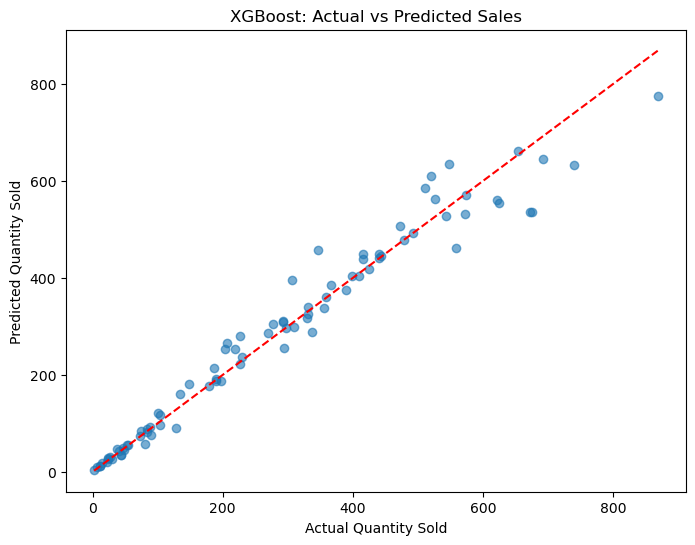

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.xlabel("Actual Quantity Sold")
plt.ylabel("Predicted Quantity Sold")
plt.title("XGBoost: Actual vs Predicted Sales")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [29]:
# forecast future sales, reggies suggestion- 3 lines
milk_data["Production Date"] = pd.to_datetime(milk_data["Production Date"])
sales_trends = (
    milk_data.groupby(milk_data["Production Date"].dt.to_period("M"))["Quantity_Sold"]
    .sum()
    .reset_index()
)
sales_trends["Production Date"] = sales_trends["Production Date"].dt.to_timestamp()
sales_trends["Date_Ordinal"] = sales_trends["Production Date"].map(pd.Timestamp.toordinal)

train_size = int(len(sales_trends) * 0.8)
train_data = sales_trends.iloc[:train_size]
test_data = sales_trends.iloc[train_size:].copy()

# ts model
X_ts = train_data[["Date_Ordinal"]]
y_ts = train_data["Quantity_Sold"]
xgb_ts_model = xgb.XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.1, random_state=42)
xgb_ts_model.fit(X_ts, y_ts)

# model forecast
X_test_timeseries = test_data[["Date_Ordinal"]]
test_data["XGBoost_Forecast"] = xgb_ts_model.predict(X_test_timeseries)

# naive forecast
test_data["Naïve_Forecast"] = train_data["Quantity_Sold"].iloc[-1]

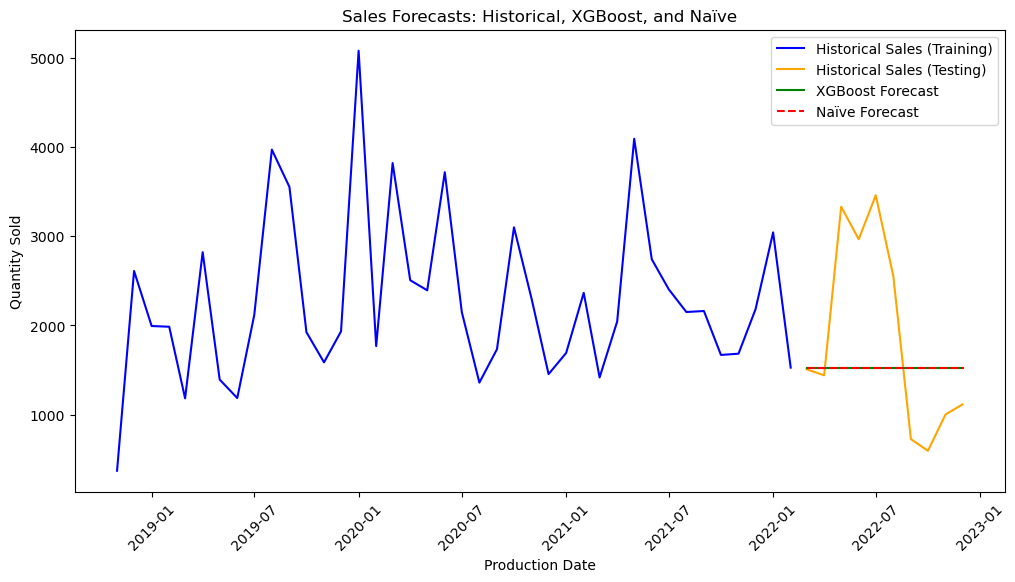

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(train_data["Production Date"], train_data["Quantity_Sold"], label="Historical Sales (Training)", color="blue")
plt.plot(test_data["Production Date"], test_data["Quantity_Sold"], label="Historical Sales (Testing)", color="orange")
plt.plot(test_data["Production Date"], test_data["XGBoost_Forecast"], label="XGBoost Forecast", color="green")
plt.plot(test_data["Production Date"], test_data["Naïve_Forecast"], label="Naïve Forecast", color="red", linestyle="--")
plt.xlabel("Production Date")
plt.ylabel("Quantity Sold")
plt.title("Sales Forecasts: Historical, XGBoost, and Naïve")
plt.legend()
plt.xticks(rotation=45)
plt.show()

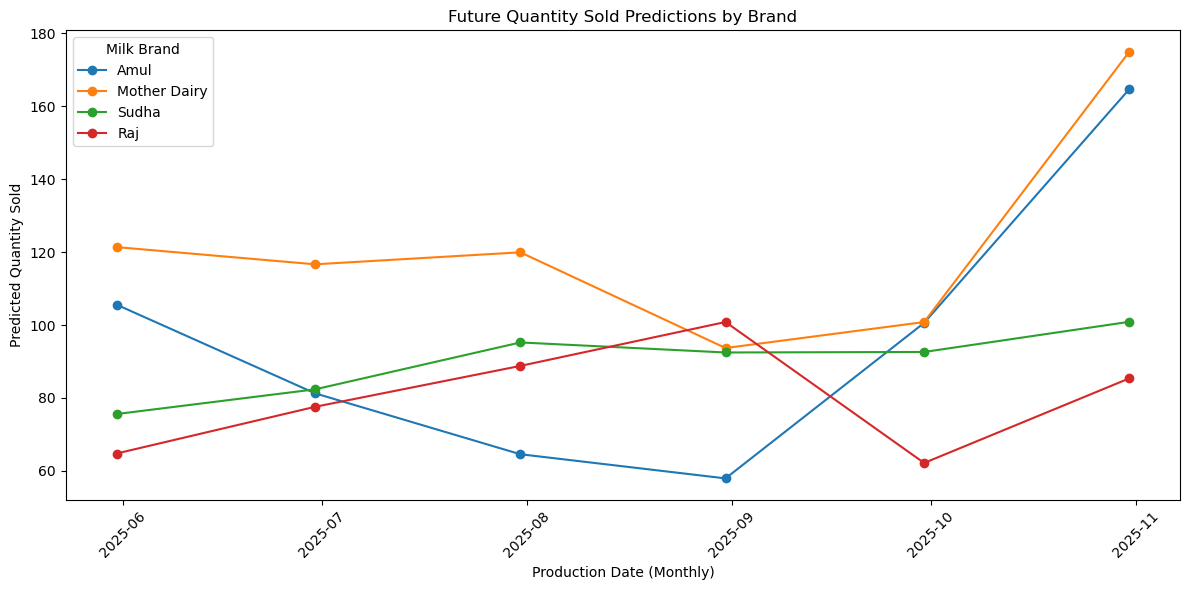

In [59]:
#ok, its ok model, lets predict the future
# add brand info
future_data = pd.DataFrame({
    "Production Date": np.tile(future_dates, len(brands)),
    "Brand": np.repeat(brands, len(future_dates)),
    "Price per Unit": np.random.uniform(50, 100, len(future_dates) * len(brands)),
    "Shelf Life (days)": np.random.choice([7, 10, 14], len(future_dates) * len(brands)),
    "Total Value": np.random.randint(5000, 10000, len(future_dates) * len(brands)),
    "Price_sold": np.random.uniform(55, 95, len(future_dates) * len(brands)),
    "Quantity in Stock (liters/kg)": np.random.randint(80, 150, len(future_dates) * len(brands)),
    "Minimum Stock Threshold (liters/kg)": np.random.randint(40, 80, len(future_dates) * len(brands)),
    "Reorder Quantity (liters/kg)": np.random.randint(30, 60, len(future_dates) * len(brands)),
    "Approx. Total Revenue(INR)": np.random.randint(5000, 10000, len(future_dates) * len(brands)),
    "Storage Condition_Tetra Pack": np.random.choice([0, 1], len(future_dates) * len(brands)),
    "Farm Size_Medium": np.random.choice([0, 1], len(future_dates) * len(brands)),
    "Farm Size_Small": np.random.choice([0, 1], len(future_dates) * len(brands)),
    "Sales Channel_Retail": np.random.choice([0, 1], len(future_dates) * len(brands)),
    "Sales Channel_Wholesale": np.random.choice([0, 1], len(future_dates) * len(brands)),
})

for col in X_train.columns:
    if col not in future_data.columns:
        future_data[col] = np.nan
        
future_data["Predicted_Quantity_Sold"] = xgb_model.predict(future_data[X_train.columns])

plt.figure(figsize=(12, 6))
for brand in future_data["Brand"].unique():
    brand_data = future_data[future_data["Brand"] == brand]
    plt.plot(brand_data["Production Date"], brand_data["Predicted_Quantity_Sold"],
             marker="o", label=brand)
plt.xlabel("Production Date (Monthly)")
plt.ylabel("Predicted Quantity Sold")
plt.title("Future Quantity Sold Predictions by Brand")
plt.xticks(rotation=45)
plt.legend(title="Milk Brand")
plt.tight_layout()
plt.show()

In [63]:
#ehhh ok , but lets see price elasticity features 

import numpy as np
import pandas as pd
brand_groups = milk_data.groupby("Brand")

milk_brand_elasticities = {}

for brand, data in brand_groups:
    past_prices = data["Price_sold"].values
    past_quantities = data["Quantity_Sold"].values
    
    price_changes = np.diff(past_prices) / past_prices[:-1]
    quantity_changes = np.diff(past_quantities) / past_quantities[:-1]

    elasticity = quantity_changes / price_changes
    avg_elasticity = np.mean(elasticity)

    optimal_price = np.mean(past_prices) * (1 + (1 / avg_elasticity))

    milk_brand_elasticities[brand] = {"Avg Elasticity": avg_elasticity, "Optimal Price": optimal_price}
    
milk_brand_elasticity_df = pd.DataFrame.from_dict(milk_brand_elasticities, orient="index")
milk_brand_elasticity_df = milk_brand_elasticity_df.sort_values(by="Optimal Price", ascending=True)

# Amul inelastic so just a placeholder max price instead
max_historical_price = milk_data[milk_data["Brand"] == "Amul"]["Price_sold"].max()

adjusted_optimal_price = min(
    max_historical_price, 
    np.mean(milk_data[milk_data["Brand"] == "Amul"]["Price_sold"]) * (1 + (1 / milk_brand_elasticity_df.loc["Amul", "Avg Elasticity"]))
)

milk_brand_elasticity_df.loc["Amul", "Optimal Price"] = adjusted_optimal_price

print(milk_brand_elasticity_df)

              Avg Elasticity  Optimal Price
Mother Dairy       -3.890399      40.910066
Raj               -36.413864      54.960270
Sudha               6.473570      60.126983
Amul                0.030123     101.500000


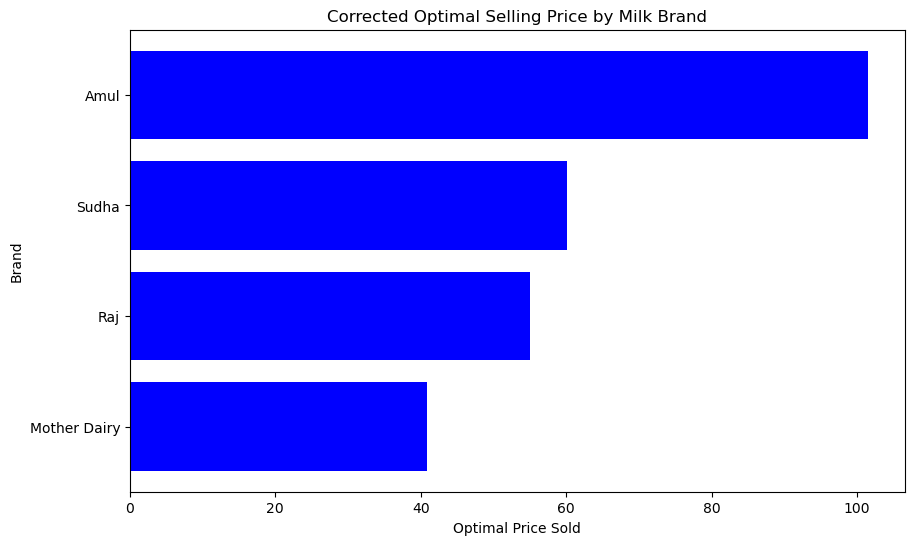

In [65]:
plt.figure(figsize=(10,6))
plt.barh(milk_brand_elasticity_df.index, milk_brand_elasticity_df["Optimal Price"], color="blue")
plt.xlabel("Optimal Price Sold")
plt.ylabel("Brand")
plt.title("Corrected Optimal Selling Price by Milk Brand")
plt.show()